# Bangkok PM2.5 Forecasting — Step 2: Preprocessing Pipeline

**Purpose**: Transform Silver-layer data into model-ready tensors for ST-UNN training.  
**Input**: Silver Parquet files (weather + air quality) from Step 1 ingestion.  
**Output**: Normalized feature tensors with chronological train/val/test splits.

### Pipeline Stages
1. Load & consolidate Silver data
2. Data quality assessment
3. Temporal alignment (hourly → daily)
4. Merge weather + air quality
5. Feature engineering (wind decomposition, lags, rolling stats, temporal encoding)
6. Hotspot integration (placeholder for VIIRS data)
7. Missing data handling
8. Chronological train/val/test split
9. Normalization (z-score using training set only)
10. Tensor preparation for ST-UNN

### Key Rules (from st-unn.mdc)
- Never mix hourly/daily without resampling
- Never use future data in training window
- Compute lag features BEFORE train-test split
- Normalize using ONLY training set statistics
- Preserve temporal order — no random shuffle
- Minimum 5-year training window

In [36]:
import subprocess, sys

def _install_if_missing(packages: list[str]) -> None:
    """Install only packages that are not already importable."""
    missing = []
    import_map = {
        "scikit-learn": "sklearn",
        "pyarrow": "pyarrow",
        "geopandas": "geopandas",
        "ipykernel": "ipykernel",
    }
    for pkg in packages:
        mod = import_map.get(pkg, pkg.split("[")[0])
        try:
            __import__(mod)
        except ImportError:
            missing.append(pkg)
    if missing:
        print(f"Installing: {missing}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)
    else:
        print("All packages already installed.")

_install_if_missing([
    "pandas", "pyarrow", "numpy", "requests",
    "matplotlib", "seaborn", "scikit-learn",
    "geopandas", "xarray", "shap",
])

# PyTorch — auto-detect backend (ROCm / MPS / CUDA / CPU)
try:
    import torch
    hip = getattr(torch.version, "hip", None)
    cuda_ver = getattr(torch.version, "cuda", None)
    has_mps = hasattr(torch.backends, "mps") and torch.backends.mps.is_available()

    if hip:
        print(f"torch {torch.__version__} — AMD ROCm ({hip})")
    elif cuda_ver and torch.cuda.is_available():
        print(f"torch {torch.__version__} — NVIDIA CUDA ({cuda_ver})")
    elif has_mps:
        print(f"torch {torch.__version__} — Apple MPS")
    else:
        print(f"torch {torch.__version__} — CPU only")
except ImportError:
    import platform as _plat
    if _plat.system() == "Darwin":
        print("torch not found — install: pip install torch torchvision torchaudio")
    else:
        print("torch not found — install ROCm/CUDA wheels or: pip install torch")

All packages already installed.
torch 2.10.0 — Apple MPS


In [37]:
from __future__ import annotations

import logging
import warnings
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import pyarrow.dataset as ds
import pyarrow.parquet as pq
import torch
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

In [38]:
@dataclass
class PipelineConfig:
    """Central configuration — single source of truth for all preprocessing parameters."""

    # --- Paths ---
    project_root: Path = Path.cwd()
    silver_weather_dir: Path = field(default=None)
    silver_aq_dir: Path = field(default=None)
    station_metadata_path: Path = field(default=None)
    output_dir: Path = field(default=None)

    # --- Spatial ---
    bangkok_lat: float = 13.7563
    bangkok_lon: float = 100.5018
    hotspot_influence_radius_km: float = 800.0

    # --- Temporal ---
    target_resolution: str = "daily"
    min_training_years: int = 5

    # --- Feature Engineering ---
    pm25_lag_days: list[int] = field(default_factory=lambda: [1, 2, 3])
    weather_lag_days: list[int] = field(default_factory=lambda: [1, 2])
    rolling_windows: list[int] = field(default_factory=lambda: [3, 7, 14])

    # --- Model Input ---
    sequence_length: int = 30
    forecast_horizons: list[int] = field(default_factory=lambda: [1, 3])

    # --- Split Ratios (chronological) ---
    train_ratio: float = 0.7
    val_ratio: float = 0.15
    test_ratio: float = 0.15

    # --- Reproducibility ---
    random_seed: int = 42

    def __post_init__(self):
        data_root = self.project_root / "data"
        if self.silver_weather_dir is None:
            self.silver_weather_dir = data_root / "silver" / "openmeteo_weather"
        if self.silver_aq_dir is None:
            self.silver_aq_dir = data_root / "silver" / "openmeteo_airquality"
        if self.station_metadata_path is None:
            self.station_metadata_path = data_root / "stations" / "bangkok_stations.parquet"
        if self.output_dir is None:
            self.output_dir = data_root / "gold" / "model_ready"

        assert abs(self.train_ratio + self.val_ratio + self.test_ratio - 1.0) < 1e-6, \
            "Split ratios must sum to 1.0"


CFG = PipelineConfig()
CFG.output_dir.mkdir(parents=True, exist_ok=True)
print(f"Project root : {CFG.project_root}")
print(f"Silver weather: {CFG.silver_weather_dir}")
print(f"Silver AQ     : {CFG.silver_aq_dir}")
print(f"Output dir    : {CFG.output_dir}")

Project root : /Users/ahcint1n/Desktop/bkk-pm25-data-ingestion
Silver weather: /Users/ahcint1n/Desktop/bkk-pm25-data-ingestion/data/silver/openmeteo_weather
Silver AQ     : /Users/ahcint1n/Desktop/bkk-pm25-data-ingestion/data/silver/openmeteo_airquality
Output dir    : /Users/ahcint1n/Desktop/bkk-pm25-data-ingestion/data/gold/model_ready


In [39]:
def setup_logging(name: str = "preprocessing") -> logging.Logger:
    """Configure structured logging for the preprocessing pipeline."""
    logger = logging.getLogger(name)
    logger.setLevel(logging.INFO)
    if not logger.handlers:
        handler = logging.StreamHandler()
        handler.setFormatter(
            logging.Formatter("%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S")
        )
        logger.addHandler(handler)
    return logger


LOG = setup_logging()

np.random.seed(CFG.random_seed)
torch.manual_seed(CFG.random_seed)
LOG.info("Random seed set to %d", CFG.random_seed)

10:14:46 [INFO] Random seed set to 42


---
## 1. Load Silver Data

Read Hive-partitioned Parquet files (`year=YYYY/month=MM/`) into DataFrames.  
Drop ingestion metadata columns — keep only measurement columns.

In [40]:
WEATHER_FEATURE_COLS = [
    "temp_c",
    "humidity_pct",
    "pressure_hpa",
    "precipitation_mm",
    "wind_ms",
    "wind_dir_deg",
    "shortwave_radiation_wm2",
    "cloud_cover_pct",
]

AQ_FEATURE_COLS = [
    "pm2_5_ugm3",
    "pm10_ugm3",
    "nitrogen_dioxide_ugm3",
    "ozone_ugm3",
    "sulphur_dioxide_ugm3",
    "carbon_monoxide_ugm3",
]

KEEP_COLS_WEATHER = ["stationID", "lat", "lon", "timestamp_utc"] + WEATHER_FEATURE_COLS
KEEP_COLS_AQ = ["stationID", "lat", "lon", "timestamp_utc"] + AQ_FEATURE_COLS


def load_silver_parquet(base_dir: Path, keep_cols: list[str], label: str) -> pd.DataFrame:
    """Load all Parquet files under a Hive-partitioned directory into a single DataFrame."""

    if not base_dir.exists():
        LOG.warning("%s directory does not exist: %s", label, base_dir)
        return pd.DataFrame(columns=keep_cols)

    parquet_files = sorted(base_dir.rglob("*.parquet"))

    if not parquet_files:
        LOG.warning("No parquet files found in %s", base_dir)
        return pd.DataFrame(columns=keep_cols)

    LOG.info("Loading %s: %d parquet files from %s", label, len(parquet_files), base_dir)

    dataset = ds.dataset(parquet_files, format="parquet")

    table = dataset.to_table(columns=keep_cols)
    df = table.to_pandas()

    # Rename AQ columns to names used in the rest of the pipeline
    df = df.rename(columns={
        "nitrogen_dioxide_ugm3": "no2_ugm3",
        "ozone_ugm3": "o3_ugm3",
        "sulphur_dioxide_ugm3": "so2_ugm3",
        "carbon_monoxide_ugm3": "co_ugm3",
    })

    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)

    df = (
        df.drop_duplicates()
        .sort_values(["stationID", "timestamp_utc"])
        .reset_index(drop=True)
    )

    LOG.info(
        "%s loaded: %s rows, %s stations, %s → %s",
        label,
        f"{len(df):,}",
        df["stationID"].nunique(),
        df["timestamp_utc"].min().strftime("%Y-%m-%d"),
        df["timestamp_utc"].max().strftime("%Y-%m-%d"),
    )

    return df

In [41]:
weather_raw = load_silver_parquet(CFG.silver_weather_dir, KEEP_COLS_WEATHER, "Weather")
weather_raw.head()

10:14:46 [INFO] Loading Weather: 191 parquet files from /Users/ahcint1n/Desktop/bkk-pm25-data-ingestion/data/silver/openmeteo_weather
10:14:53 [INFO] Weather loaded: 10,899,744 rows, 80 stations, 2010-01-01 → 2026-02-24


,stationID,lat,lon,timestamp_utc,temp_c,humidity_pct,pressure_hpa,precipitation_mm,wind_ms,wind_dir_deg,shortwave_radiation_wm2,cloud_cover_pct
0,02t,13.732846,100.487662,2010-01-01 00:00:00+00:00,24.700001,96.0,1008.799988,0.0,4.6,141.0,3.0,20.0
1,02t,13.732846,100.487662,2010-01-01 01:00:00+00:00,26.600000,86.0,1009.799988,0.0,5.2,146.0,109.0,48.0
2,02t,13.732846,100.487662,2010-01-01 02:00:00+00:00,28.200001,74.0,1010.400024,0.0,4.6,162.0,314.0,33.0
3,02t,13.732846,100.487662,2010-01-01 03:00:00+00:00,29.500000,66.0,1010.799988,0.2,3.2,180.0,509.0,42.0
4,02t,13.732846,100.487662,2010-01-01 04:00:00+00:00,30.100000,63.0,1010.500000,0.2,2.6,164.0,543.0,52.0


In [42]:
import pyarrow.dataset as ds

dataset = ds.dataset(CFG.silver_aq_dir, format="parquet")
print(dataset.schema)

stationID: large_string
lat: double
lon: double
timestamp_utc: timestamp[us, tz=UTC]
timestamp_unix_ms: int64
pm2_5_ugm3: double
pm10_ugm3: double
nitrogen_dioxide_ugm3: double
ozone_ugm3: double
sulphur_dioxide_ugm3: double
carbon_monoxide_ugm3: double
data_source: large_string
ingestion_timestamp_utc: timestamp[us]
load_id: large_string
pipeline_version: large_string
record_hash: large_string


In [43]:
aq_raw = load_silver_parquet(CFG.silver_aq_dir, KEEP_COLS_AQ, "Air Quality")
aq_raw.head()

10:14:53 [INFO] Loading Air Quality: 3487 parquet files from /Users/ahcint1n/Desktop/bkk-pm25-data-ingestion/data/silver/openmeteo_airquality
10:14:56 [INFO] Air Quality loaded: 4,281,768 rows, 79 stations, 2019-01-01 → 2026-02-28


,stationID,lat,lon,timestamp_utc,pm2_5_ugm3,pm10_ugm3,no2_ugm3,o3_ugm3,so2_ugm3,co_ugm3
0,02t,13.700005,100.5,2019-01-01 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN
1,02t,13.700005,100.5,2019-01-01 01:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN
2,02t,13.700005,100.5,2019-01-01 02:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN
3,02t,13.700005,100.5,2019-01-01 03:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN
4,02t,13.700005,100.5,2019-01-01 04:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
def load_station_metadata(path: Path) -> pd.DataFrame:
    """Load Bangkok station metadata with lat/lon for spatial reference."""
    if not path.exists():
        LOG.warning("Station metadata not found: %s", path)
        return pd.DataFrame()
    stations = pd.read_parquet(path)
    LOG.info("Loaded %d stations from metadata", len(stations))
    return stations


stations_meta = load_station_metadata(CFG.station_metadata_path)
stations_meta

10:14:56 [INFO] Loaded 79 stations from metadata


,stationID,stationName,areaEN,lat,lon
0,02t,Bansomdejchaopraya Rajabhat University,"Hiran Ruchi, Khet Thon Buri, Bangkok",13.732846,100.487662
1,03t,Highway NO.3902 km.13 +600,"Kanchanaphisek Rd, Bang Khun Thian, Bangkok",13.636514,100.414262
2,05t,Thai Meteorological Department,"Bang Na, Khet Bang Na, Bangkok",13.666183,100.605742
3,12t,Nonsi Witthaya School,"Chong Nonsi, Khet Yannawa, Bangkok",13.708067,100.547333
4,50t,Chulalongkorn Hospital,"Rama IV Rd. Khet Pathum Wan, Bangkok",13.729852,100.536501
...,...,...,...,...,...
74,bkp96t,"Ladphrao District Office, Bangkok","Ladphrao, Bangkok",13.803587,100.607535
75,bkp97t,"Lak Si District Office, Bangkok","Thung Song Hong, Lak Si, Bangkok",13.887395,100.579247
76,bkp98t,"Bang Khen District Office, Bangkok","Phahon Yothin Roadside, Bang Khen, Bangkok",13.873603,100.595839
77,bkp99t,"Saphan Sung District Office, Bangkok","Saphan Sung, Bangkok",13.768892,100.685743


---
## 2. Data Quality Assessment

Check missingness, date coverage, duplicates, and physical plausibility.

In [45]:
def data_quality_report(df: pd.DataFrame, label: str) -> pd.DataFrame:
    """Generate a per-column data quality summary: type, non-null count, missing %, min/max."""
    if df.empty:
        print(f"[{label}] DataFrame is empty — skipping DQ report.")
        return pd.DataFrame()

    report = pd.DataFrame({
        "dtype": df.dtypes,
        "non_null": df.notna().sum(),
        "null_count": df.isna().sum(),
        "null_pct": (df.isna().sum() / len(df) * 100).round(2),
    })

    numeric_cols = df.select_dtypes(include=["number"]).columns
    for col in numeric_cols:
        report.loc[col, "min"] = df[col].min()
        report.loc[col, "max"] = df[col].max()
        report.loc[col, "mean"] = df[col].mean()

    print(f"\n{'='*60}")
    print(f"  Data Quality Report: {label}")
    print(f"  Rows: {len(df):,}  |  Columns: {len(df.columns)}")
    print(f"{'='*60}")
    print(report.to_string())
    return report

In [46]:
dq_weather = data_quality_report(weather_raw, "Weather (Hourly)")


  Data Quality Report: Weather (Hourly)
  Rows: 10,899,744  |  Columns: 12
                                       dtype  non_null  null_count  null_pct         min          max         mean
stationID                                str  10899744           0       0.0         NaN          NaN          NaN
lat                                  float64  10899744           0       0.0   13.636514    13.928868    13.755338
lon                                  float64  10899744           0       0.0  100.343164   100.862670   100.560807
timestamp_utc            datetime64[ns, UTC]  10899744           0       0.0         NaN          NaN          NaN
temp_c                               float32  10899744           0       0.0   12.700000    40.200001    27.903715
humidity_pct                         float32  10899744           0       0.0   16.000000   100.000000    74.694466
pressure_hpa                         float32  10899744           0       0.0  997.500000  1022.799988  1008.633423
prec

In [47]:
dq_aq = data_quality_report(aq_raw, "Air Quality (Hourly)")


  Data Quality Report: Air Quality (Hourly)
  Rows: 4,281,768  |  Columns: 10
                             dtype  non_null  null_count  null_pct         min           max        mean
stationID                      str   4281768           0      0.00         NaN           NaN         NaN
lat                        float64   4281768           0      0.00   13.599998     13.928868   13.755990
lon                        float64   4281768           0      0.00  100.300020    100.899994  100.561249
timestamp_utc  datetime64[us, UTC]   4281768           0      0.00         NaN           NaN         NaN
pm2_5_ugm3                 float64   3550488      731280     17.08    0.800000    549.500000   26.670307
pm10_ugm3                  float64   3550488      731280     17.08    1.100000    786.000000   34.081126
no2_ugm3                   float64   1478160     2803608     65.48    0.000000    731.200000   26.526850
o3_ugm3                    float64   1478160     2803608     65.48    0.000000   

In [48]:
def check_date_coverage(df: pd.DataFrame, station_col: str, ts_col: str, label: str) -> None:
    """Report date range and continuity per station."""
    if df.empty:
        print(f"[{label}] No data to check coverage.")
        return

    summary = (
        df.groupby(station_col)[ts_col]
        .agg(["min", "max", "count"])
        .rename(columns={"min": "first_date", "max": "last_date", "count": "records"})
    )
    summary["days_span"] = (summary["last_date"] - summary["first_date"]).dt.days
    summary["expected_hourly"] = summary["days_span"] * 24
    summary["coverage_pct"] = (summary["records"] / summary["expected_hourly"].clip(lower=1) * 100).round(1)

    print(f"\n{'='*60}")
    print(f"  Date Coverage: {label}")
    print(f"{'='*60}")
    print(summary.to_string())


check_date_coverage(weather_raw, "stationID", "timestamp_utc", "Weather")
check_date_coverage(aq_raw, "stationID", "timestamp_utc", "Air Quality")


  Date Coverage: Weather
                         first_date                 last_date  records  days_span  expected_hourly  coverage_pct
stationID                                                                                                       
02t       2010-01-01 00:00:00+00:00 2026-02-24 23:00:00+00:00   139368       5898           141552          98.5
03t       2010-01-01 00:00:00+00:00 2026-02-24 23:00:00+00:00   139368       5898           141552          98.5
05t       2010-01-01 00:00:00+00:00 2026-02-24 23:00:00+00:00   139368       5898           141552          98.5
12t       2010-01-01 00:00:00+00:00 2026-02-24 23:00:00+00:00   139368       5898           141552          98.5
50t       2010-01-01 00:00:00+00:00 2026-02-24 23:00:00+00:00   139368       5898           141552          98.5
52t       2010-01-01 00:00:00+00:00 2026-02-24 23:00:00+00:00   139368       5898           141552          98.5
53t       2010-01-01 00:00:00+00:00 2026-02-24 23:00:00+00:00   139368

---
## 3. Temporal Alignment — Hourly to Daily Aggregation

Aggregate hourly data to daily resolution with physically appropriate methods:  
- **Temperature**: daily mean  
- **Precipitation**: daily sum  
- **Wind speed/direction**: vector mean  
- **PM2.5**: daily mean  
- **Radiation**: daily sum (total energy)

In [49]:
DAILY_AGG_WEATHER = {
    "temp_c":                   "mean",
    "humidity_pct":             "mean",
    "pressure_hpa":             "mean",
    "precipitation_mm":         "sum",
    "wind_ms":                  "mean",
    "wind_dir_deg":             "first",  # placeholder — replaced by vector mean below
    "shortwave_radiation_wm2":  "sum",
    "cloud_cover_pct":          "mean",
}

DAILY_AGG_AQ = {
    "pm2_5_ugm3": "mean",
    "pm10_ugm3":  "mean",
    "no2_ugm3":   "mean",
    "o3_ugm3":    "mean",
    "so2_ugm3":   "mean",
    "co_ugm3":    "mean",
}

SOLAR_NOON_HOUR_UTC = 5  # Bangkok ~12:00 local = 05:00 UTC


def compute_daily_wind_vector(group: pd.DataFrame) -> pd.Series:
    """Compute vector-averaged wind direction and mean wind speed for a day.

    Using vector decomposition avoids the wraparound problem (e.g. 350° vs 10°).
    """
    speed = group["wind_ms"].values
    direction_rad = np.deg2rad(group["wind_dir_deg"].values)

    valid = ~(np.isnan(speed) | np.isnan(direction_rad))
    if valid.sum() == 0:
        return pd.Series({"wind_ms": np.nan, "wind_dir_deg": np.nan})

    u = -speed[valid] * np.sin(direction_rad[valid])
    v = -speed[valid] * np.cos(direction_rad[valid])

    u_mean = u.mean()
    v_mean = v.mean()

    mean_speed = np.sqrt(u_mean**2 + v_mean**2)
    mean_dir = (np.rad2deg(np.arctan2(-u_mean, -v_mean)) + 360) % 360

    return pd.Series({"wind_ms": mean_speed, "wind_dir_deg": mean_dir})


def aggregate_to_daily(
    df: pd.DataFrame,
    agg_map: dict[str, str],
    label: str,
    solar_noon_hour_utc: int = SOLAR_NOON_HOUR_UTC,
) -> pd.DataFrame:
    """Aggregate hourly records to daily, aligned to solar noon for DQ consistency."""
    if df.empty:
        LOG.warning("%s: empty DataFrame — skipping aggregation.", label)
        return df

    df = df.copy()
    df["date"] = (
        df["timestamp_utc"]
        .dt.tz_localize(None)
        .sub(pd.Timedelta(hours=solar_noon_hour_utc))
        .dt.date
    )
    df["date"] = pd.to_datetime(df["date"])

    has_wind_vector = "wind_ms" in agg_map and "wind_dir_deg" in agg_map

    agg_no_wind = {k: v for k, v in agg_map.items() if k not in ("wind_ms", "wind_dir_deg")}

    grouped = df.groupby(["stationID", "date"])

    daily = grouped.agg(agg_no_wind).reset_index()

    if has_wind_vector:
        wind_daily = grouped.apply(compute_daily_wind_vector, include_groups=False).reset_index()
        daily = daily.merge(wind_daily, on=["stationID", "date"], how="left", suffixes=("", "_vec"))
        if "wind_ms_vec" in daily.columns:
            daily["wind_ms"] = daily["wind_ms_vec"]
            daily["wind_dir_deg"] = daily["wind_dir_deg_vec"]
            daily.drop(columns=["wind_ms_vec", "wind_dir_deg_vec"], inplace=True)

    lat_lon = df.groupby("stationID")[["lat", "lon"]].first().reset_index()
    daily = daily.merge(lat_lon, on="stationID", how="left")

    daily = daily.sort_values(["stationID", "date"]).reset_index(drop=True)

    LOG.info("%s daily aggregation: %s hourly → %s daily rows", label, f"{len(df):,}", f"{len(daily):,}")
    return daily

In [50]:
weather_daily = aggregate_to_daily(weather_raw, DAILY_AGG_WEATHER, "Weather")
weather_daily.head()

10:16:14 [INFO] Weather daily aggregation: 10,899,744 hourly → 454,365 daily rows


,stationID,date,temp_c,humidity_pct,pressure_hpa,precipitation_mm,shortwave_radiation_wm2,cloud_cover_pct,wind_ms,wind_dir_deg,lat,lon
0,02t,2009-12-31,27.820002,77.000000,1010.059937,0.4,1478.0,39.000000,3.927433,156.147888,13.732846,100.487662
1,02t,2010-01-01,27.912500,76.041664,1008.883301,0.1,4397.0,46.833332,5.821934,180.840561,13.732846,100.487662
2,02t,2010-01-02,27.704168,76.083336,1009.700012,0.0,4904.0,31.083334,3.782737,188.741241,13.732846,100.487662
3,02t,2010-01-03,28.754166,69.125000,1008.670837,0.0,5299.0,55.375000,4.122314,180.564209,13.732846,100.487662
4,02t,2010-01-04,28.245834,76.041664,1007.879150,0.3,4455.0,40.250000,10.743492,179.636597,13.732846,100.487662


In [51]:
aq_daily = aggregate_to_daily(aq_raw, DAILY_AGG_AQ, "Air Quality")
aq_daily.head()

10:16:15 [INFO] Air Quality daily aggregation: 4,281,768 hourly → 118,720 daily rows


,stationID,date,pm2_5_ugm3,pm10_ugm3,no2_ugm3,o3_ugm3,so2_ugm3,co_ugm3,lat,lon
0,02t,2018-12-31,NaN,NaN,NaN,NaN,NaN,NaN,13.700005,100.5
1,02t,2019-01-01,NaN,NaN,NaN,NaN,NaN,NaN,13.700005,100.5
2,02t,2019-01-02,NaN,NaN,NaN,NaN,NaN,NaN,13.700005,100.5
3,02t,2019-01-03,NaN,NaN,NaN,NaN,NaN,NaN,13.700005,100.5
4,02t,2019-01-04,NaN,NaN,NaN,NaN,NaN,NaN,13.700005,100.5


---
## 4. Merge Weather + Air Quality

Join on `(stationID, date)`. If AQ data is not yet available, proceed with weather-only features  
and mark AQ columns as NaN (to be filled once AQ ingestion is fixed).

In [52]:
def merge_weather_aq(
    weather: pd.DataFrame,
    aq: pd.DataFrame,
) -> pd.DataFrame:
    """Merge weather and air quality on (stationID, date) with an outer join.

    Outer join ensures no data is lost — missing AQ rows get NaN for pollutant columns.
    """
    if weather.empty:
        LOG.error("Weather data is empty — cannot proceed.")
        raise ValueError("Weather data is required for merge.")

    if aq.empty:
        LOG.warning("Air quality data is empty — creating placeholder NaN columns.")
        for col in AQ_FEATURE_COLS:
            weather[col] = np.nan
        return weather

    aq_merge_cols = ["stationID", "date"] + AQ_FEATURE_COLS
    aq_subset = aq[[c for c in aq_merge_cols if c in aq.columns]]

    merged = weather.merge(aq_subset, on=["stationID", "date"], how="outer")

    merged = merged.sort_values(["stationID", "date"]).reset_index(drop=True)

    LOG.info("Merged dataset: %s rows, %d columns", f"{len(merged):,}", len(merged.columns))
    return merged


merged_daily = merge_weather_aq(weather_daily, aq_daily)
print(f"Shape: {merged_daily.shape}")
merged_daily.head()

10:16:16 [INFO] Merged dataset: 461,870 rows, 14 columns


Shape: (461870, 14)


,stationID,date,temp_c,humidity_pct,pressure_hpa,precipitation_mm,shortwave_radiation_wm2,cloud_cover_pct,wind_ms,wind_dir_deg,lat,lon,pm2_5_ugm3,pm10_ugm3
0,02t,2009-12-31,27.820002,77.000000,1010.059937,0.4,1478.0,39.000000,3.927433,156.147888,13.732846,100.487662,NaN,NaN
1,02t,2010-01-01,27.912500,76.041664,1008.883301,0.1,4397.0,46.833332,5.821934,180.840561,13.732846,100.487662,NaN,NaN
2,02t,2010-01-02,27.704168,76.083336,1009.700012,0.0,4904.0,31.083334,3.782737,188.741241,13.732846,100.487662,NaN,NaN
3,02t,2010-01-03,28.754166,69.125000,1008.670837,0.0,5299.0,55.375000,4.122314,180.564209,13.732846,100.487662,NaN,NaN
4,02t,2010-01-04,28.245834,76.041664,1007.879150,0.3,4455.0,40.250000,10.743492,179.636597,13.732846,100.487662,NaN,NaN


---
## 5. Feature Engineering

### 5a. Wind Vector Decomposition  
Convert speed + direction → u10 (eastward) & v10 (northward) components.  
Wind components are physically more meaningful than angular direction for ML.

In [53]:
def add_wind_components(df: pd.DataFrame) -> pd.DataFrame:
    """Decompose wind speed + direction into u10 (eastward) and v10 (northward) components."""
    df = df.copy()
    direction_rad = np.deg2rad(df["wind_dir_deg"].values)

    df["wind_u10"] = -df["wind_ms"] * np.sin(direction_rad)
    df["wind_v10"] = -df["wind_ms"] * np.cos(direction_rad)

    LOG.info("Added wind_u10 and wind_v10 components")
    return df


merged_daily = add_wind_components(merged_daily)
merged_daily[["wind_ms", "wind_dir_deg", "wind_u10", "wind_v10"]].describe()

10:16:16 [INFO] Added wind_u10 and wind_v10 components


,wind_ms,wind_dir_deg,wind_u10,wind_v10
count,454365.000000,454365.000000,454365.000000,454365.000000
mean,7.571545,167.652344,0.945611,2.975505
std,3.461133,86.528305,4.479497,6.284436
min,0.006382,0.010071,-17.271410,-20.481318
25%,4.992412,92.368256,-1.811827,-1.979991
50%,7.535444,184.844666,0.519261,3.922274
75%,9.964086,223.230072,3.740836,7.442456
max,21.191509,359.995819,17.736828,19.904335


### 5b. Lag Features  
Create lagged values BEFORE train/test split to avoid data leakage from the split boundary.  
Lags are computed per station to prevent cross-station contamination.

In [54]:
def add_lag_features(
    df: pd.DataFrame,
    target_col: str,
    lag_days: list[int],
    group_col: str = "stationID",
) -> pd.DataFrame:
    """Add lag features for a target column, computed per station group."""
    df = df.copy()
    for lag in lag_days:
        col_name = f"{target_col}_lag{lag}"
        df[col_name] = df.groupby(group_col)[target_col].shift(lag)
    return df


def add_all_lag_features(df: pd.DataFrame, cfg: PipelineConfig) -> pd.DataFrame:
    """Add all lag features as specified in configuration."""
    # PM2.5 lags
    if "pm2_5_ugm3" in df.columns:
        df = add_lag_features(df, "pm2_5_ugm3", cfg.pm25_lag_days)
        LOG.info("Added PM2.5 lags: %s", cfg.pm25_lag_days)

    # Weather variable lags
    weather_lag_targets = ["temp_c", "humidity_pct", "pressure_hpa", "wind_u10", "wind_v10"]
    for col in weather_lag_targets:
        if col in df.columns:
            df = add_lag_features(df, col, cfg.weather_lag_days)
    LOG.info("Added weather lags for %d variables", len(weather_lag_targets))

    return df


merged_daily = add_all_lag_features(merged_daily, CFG)
lag_cols = [c for c in merged_daily.columns if "_lag" in c]
print(f"Lag features created: {lag_cols}")

10:16:16 [INFO] Added PM2.5 lags: [1, 2, 3]
10:16:16 [INFO] Added weather lags for 5 variables


Lag features created: ['pm2_5_ugm3_lag1', 'pm2_5_ugm3_lag2', 'pm2_5_ugm3_lag3', 'temp_c_lag1', 'temp_c_lag2', 'humidity_pct_lag1', 'humidity_pct_lag2', 'pressure_hpa_lag1', 'pressure_hpa_lag2', 'wind_u10_lag1', 'wind_u10_lag2', 'wind_v10_lag1', 'wind_v10_lag2']


### 5c. Rolling Statistics  
Capture short/medium-term trends via rolling mean and standard deviation.

In [55]:
def add_rolling_features(
    df: pd.DataFrame,
    columns: list[str],
    windows: list[int],
    group_col: str = "stationID",
) -> pd.DataFrame:
    """Add rolling mean and std for specified columns and window sizes."""
    df = df.copy()
    for col in columns:
        if col not in df.columns:
            continue
        grouped = df.groupby(group_col)[col]
        for w in windows:
            df[f"{col}_rmean{w}"] = grouped.transform(
                lambda x: x.rolling(window=w, min_periods=1).mean()
            )
            df[f"{col}_rstd{w}"] = grouped.transform(
                lambda x: x.rolling(window=w, min_periods=2).std()
            )
    return df


rolling_targets = ["pm2_5_ugm3", "temp_c", "humidity_pct", "wind_ms"]
merged_daily = add_rolling_features(merged_daily, rolling_targets, CFG.rolling_windows)

rolling_cols = [c for c in merged_daily.columns if "_rmean" in c or "_rstd" in c]
LOG.info("Added %d rolling features", len(rolling_cols))

10:16:16 [INFO] Added 24 rolling features


### 5d. Temporal Encodings  
Cyclical encoding of day-of-year and month to preserve periodicity (sin/cos).

In [56]:
def add_temporal_encodings(df: pd.DataFrame) -> pd.DataFrame:
    """Add cyclical sin/cos encodings for day-of-year and month."""
    df = df.copy()

    day_of_year = df["date"].dt.dayofyear
    days_in_year = df["date"].dt.is_leap_year.map({True: 366, False: 365})
    df["doy_sin"] = np.sin(2 * np.pi * day_of_year / days_in_year)
    df["doy_cos"] = np.cos(2 * np.pi * day_of_year / days_in_year)

    month = df["date"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * month / 12)
    df["month_cos"] = np.cos(2 * np.pi * month / 12)

    LOG.info("Added temporal encodings: doy_sin, doy_cos, month_sin, month_cos")
    return df


merged_daily = add_temporal_encodings(merged_daily)
merged_daily[["date", "doy_sin", "doy_cos", "month_sin", "month_cos"]].head()

10:16:17 [INFO] Added temporal encodings: doy_sin, doy_cos, month_sin, month_cos


,date,doy_sin,doy_cos,month_sin,month_cos
0,2009-12-31,6.432491e-16,1.000000,-2.449294e-16,1.000000
1,2010-01-01,1.721336e-02,0.999852,5.000000e-01,0.866025
2,2010-01-02,3.442161e-02,0.999407,5.000000e-01,0.866025
3,2010-01-03,5.161967e-02,0.998667,5.000000e-01,0.866025
4,2010-01-04,6.880243e-02,0.997630,5.000000e-01,0.866025


### 5e. Hotspot / Transboundary Index (Placeholder)

When VIIRS hotspot data becomes available, integrate here:  
- `hotspot_count_th`, `hotspot_count_mm`, `hotspot_count_la`  
- `hotspot_frp_sum`  
- `TBI` (Transboundary Index): `Σ(FRP_upwind × wind_speed × exp(-distance/decay_factor))`

In [57]:
# Hotspot features from NASA FIRMS (bronze) — region counts + lags
from src.hotspot_features import (
    build_hotspot_feature_table,
    merge_hotspot_features_into_daily,
    HOTSPOT_REGION_COLS,
)

bronze_hotspot_dir = CFG.project_root / "data" / "bronze" / "raw_hotspot"
hotspot_feature_df = build_hotspot_feature_table(bronze_hotspot_dir)
merged_daily = merge_hotspot_features_into_daily(merged_daily, hotspot_feature_df, date_col="date")

# Drop legacy placeholder columns if present (replaced by hotspot_<region> and *_lag1/2/3)
for col in ["hotspot_count_th", "hotspot_count_mm", "hotspot_count_la", "hotspot_frp_sum", "transboundary_index"]:
    if col in merged_daily.columns:
        merged_daily = merged_daily.drop(columns=[col])

LOG.info(
    "Hotspot features merged: %s region columns + lags (e.g. %s)",
    len(HOTSPOT_REGION_COLS),
    [c for c in merged_daily.columns if "hotspot_" in c][:5],
)

10:16:47 [INFO] Hotspot features merged: 8 region columns + lags (e.g. ['hotspot_thailand', 'hotspot_myanmar', 'hotspot_laos', 'hotspot_cambodia', 'hotspot_vietnam'])


---
## 6. Missing Data Handling

Strategy:  
1. **Small gaps (≤ 3 days)**: linear interpolation per station  
2. **Large gaps**: leave as NaN (will be masked during training)  
3. **Columns with > 50% missing**: flag for review (do not drop yet)

In [58]:
MAX_INTERPOLATION_GAP = 3  # days
HIGH_MISSING_THRESHOLD = 0.50

merged_daily = merged_daily[merged_daily["date"] >= "2023-01-01"]

def handle_missing_data(
    df: pd.DataFrame,
    max_gap: int = MAX_INTERPOLATION_GAP,
    group_col: str = "stationID",
) -> pd.DataFrame:
    """Interpolate small gaps per station; flag columns with high missingness."""
    df = df.copy()

    # Remove test station if present
    df = df[df[group_col] != "test_bkk"]

    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    exclude = {"lat", "lon"}
    interpolate_cols = [c for c in numeric_cols if c not in exclude]

    before_null = df[interpolate_cols].isna().sum().sum()

    df[interpolate_cols] = (
        df.groupby(group_col)[interpolate_cols]
        .transform(lambda g: g.interpolate(method="linear", limit=max_gap, limit_direction="forward"))
    )

    after_null = df[interpolate_cols].isna().sum().sum()
    LOG.info("Interpolation filled %d NaN values (limit=%d days)", before_null - after_null, max_gap)

    missing_pct = df[interpolate_cols].isna().mean()
    high_missing = missing_pct[missing_pct > HIGH_MISSING_THRESHOLD]

    if not high_missing.empty:
        LOG.warning("Columns with >%.0f%% missing after interpolation:", HIGH_MISSING_THRESHOLD * 100)
        for col, pct in high_missing.items():
            LOG.warning("  %s: %.1f%% missing", col, pct * 100)

    return df


merged_daily = handle_missing_data(merged_daily)

print("\nRemaining NaN per column:")
remaining = merged_daily.isna().sum()
print(remaining[remaining > 0].to_string())

10:16:47 [INFO] Interpolation filled 61690 NaN values (limit=3 days)



Remaining NaN per column:
temp_c                        7031
humidity_pct                  7031
pressure_hpa                  7031
precipitation_mm              7031
shortwave_radiation_wm2       7031
cloud_cover_pct               7031
wind_ms                       7031
wind_dir_deg                  7031
lat                           7505
lon                           7505
pm2_5_ugm3                    3030
pm10_ugm3                     3030
wind_u10                      7031
wind_v10                      7031
pm2_5_ugm3_lag1               3086
pm2_5_ugm3_lag2               3165
pm2_5_ugm3_lag3               3244
temp_c_lag1                   6952
temp_c_lag2                   6952
humidity_pct_lag1             6952
humidity_pct_lag2             6952
pressure_hpa_lag1             6952
pressure_hpa_lag2             6952
wind_u10_lag1                 6952
wind_u10_lag2                 6952
wind_v10_lag1                 6952
wind_v10_lag2                 6952
pm2_5_ugm3_rmean3           

---
## 7. Outlier Detection

Apply physical plausibility bounds. Values outside these ranges are clipped (not removed)  
to maintain temporal continuity.

In [59]:
PHYSICAL_BOUNDS = {
    "temp_c":            (-10, 55),
    "humidity_pct":      (0, 100),
    "pressure_hpa":     (900, 1100),
    "precipitation_mm": (0, 500),
    "wind_ms":           (0, 50),
    "cloud_cover_pct":  (0, 100),
    "pm2_5_ugm3":       (0, 1000),
    "pm10_ugm3":        (0, 2000),
    "no2_ugm3":         (0, 500),
    "o3_ugm3":          (0, 500),
    "so2_ugm3":         (0, 500),
    "co_ugm3":          (0, 50000),
}


def clip_physical_bounds(df: pd.DataFrame, bounds: dict[str, tuple]) -> pd.DataFrame:
    """Clip values to physically plausible ranges and log clipping counts."""
    df = df.copy()
    total_clipped = 0
    for col, (lo, hi) in bounds.items():
        if col not in df.columns:
            continue
        below = (df[col] < lo).sum()
        above = (df[col] > hi).sum()
        if below + above > 0:
            LOG.info("Clipping %s: %d below %.1f, %d above %.1f", col, below, lo, above, hi)
            total_clipped += below + above
        df[col] = df[col].clip(lower=lo, upper=hi)
    LOG.info("Total values clipped: %d", total_clipped)
    return df


merged_daily = clip_physical_bounds(merged_daily, PHYSICAL_BOUNDS)

10:16:47 [INFO] Total values clipped: 0


---
## 8. Feature Inventory

Define which columns serve which role before splitting.

In [60]:
ID_COLS = ["stationID", "date", "lat", "lon"]
TARGET_COL = "pm2_5_ugm3"

FEATURE_COLS = sorted([
    c for c in merged_daily.columns
    if c not in ID_COLS + [TARGET_COL]
    and merged_daily[c].dtype in ["float32", "float64", "int64"]
])

print(f"Target    : {TARGET_COL}")
print(f"ID cols   : {ID_COLS}")
print(f"Features  : {len(FEATURE_COLS)} columns")
print(f"\nFeature list:")
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"  {i:3d}. {col}")

Target    : pm2_5_ugm3
ID cols   : ['stationID', 'date', 'lat', 'lon']
Features  : 84 columns

Feature list:
    1. cloud_cover_pct
    2. doy_cos
    3. doy_sin
    4. hotspot_cambodia
    5. hotspot_cambodia_lag1
    6. hotspot_cambodia_lag2
    7. hotspot_cambodia_lag3
    8. hotspot_china_yunnan
    9. hotspot_china_yunnan_lag1
   10. hotspot_china_yunnan_lag2
   11. hotspot_china_yunnan_lag3
   12. hotspot_indonesia
   13. hotspot_indonesia_lag1
   14. hotspot_indonesia_lag2
   15. hotspot_indonesia_lag3
   16. hotspot_laos
   17. hotspot_laos_lag1
   18. hotspot_laos_lag2
   19. hotspot_laos_lag3
   20. hotspot_malaysia
   21. hotspot_malaysia_lag1
   22. hotspot_malaysia_lag2
   23. hotspot_malaysia_lag3
   24. hotspot_myanmar
   25. hotspot_myanmar_lag1
   26. hotspot_myanmar_lag2
   27. hotspot_myanmar_lag3
   28. hotspot_thailand
   29. hotspot_thailand_lag1
   30. hotspot_thailand_lag2
   31. hotspot_thailand_lag3
   32. hotspot_vietnam
   33. hotspot_vietnam_lag1
   34. hot

---
## 9. Chronological Train / Val / Test Split

**Critical**: No random shuffling. Data is split by date to prevent future leakage.  
Minimum 5-year training window enforced.

In [61]:
def chronological_split(
    df: pd.DataFrame,
    date_col: str,
    train_ratio: float,
    val_ratio: float,
    min_train_years: int,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Split data chronologically into train/val/test sets.

    Ensures the training period is at least `min_train_years` years long.
    All stations share the same date boundaries to prevent temporal leakage.
    """
    unique_dates = sorted(df[date_col].unique())
    n_dates = len(unique_dates)

    if n_dates == 0:
        raise ValueError("No dates in dataset")

    train_end_idx = int(n_dates * train_ratio)
    val_end_idx = int(n_dates * (train_ratio + val_ratio))

    train_cutoff = unique_dates[train_end_idx]
    val_cutoff = unique_dates[min(val_end_idx, n_dates - 1)]

    date_range_years = (unique_dates[-1] - unique_dates[0]).days / 365.25
    train_years = (train_cutoff - unique_dates[0]).days / 365.25

    if train_years < min_train_years:
        LOG.warning(
            "Training period is only %.1f years (minimum %d required). "
            "Total data covers %.1f years.",
            train_years, min_train_years, date_range_years,
        )

    train = df[df[date_col] < train_cutoff].copy()
    val = df[(df[date_col] >= train_cutoff) & (df[date_col] < val_cutoff)].copy()
    test = df[df[date_col] >= val_cutoff].copy()

    LOG.info("Split boundaries:")
    LOG.info("  Train: %s → %s (%d days, %s rows)",
             unique_dates[0].strftime("%Y-%m-%d"), train_cutoff.strftime("%Y-%m-%d"),
             train_end_idx, f"{len(train):,}")
    LOG.info("  Val  : %s → %s (%d days, %s rows)",
             train_cutoff.strftime("%Y-%m-%d"), val_cutoff.strftime("%Y-%m-%d"),
             val_end_idx - train_end_idx, f"{len(val):,}")
    LOG.info("  Test : %s → %s (%d days, %s rows)",
             val_cutoff.strftime("%Y-%m-%d"), unique_dates[-1].strftime("%Y-%m-%d"),
             n_dates - val_end_idx, f"{len(test):,}")

    return train, val, test


df_train, df_val, df_test = chronological_split(
    merged_daily, "date", CFG.train_ratio, CFG.val_ratio, CFG.min_training_years
)

10:16:47 [WARNING] Training period is only 2.2 years (minimum 5 required). Total data covers 3.2 years.
10:16:47 [INFO] Split boundaries:
10:16:47 [INFO]   Train: 2023-01-01 → 2025-03-19 (808 days, 63,832 rows)
10:16:47 [INFO]   Val  : 2025-03-19 → 2025-09-08 (173 days, 13,667 rows)
10:16:47 [INFO]   Test : 2025-09-08 → 2026-02-28 (174 days, 13,746 rows)


---
## 10. Normalization (Z-Score — Training Set Only)

Compute mean and std from the **training set only**, then apply to val/test.  
This prevents information leakage from future data.

In [62]:
@dataclass
class NormalizationStats:
    """Stores per-feature mean and std from the training set for reproducible normalization."""
    mean: pd.Series
    std: pd.Series

    def save(self, path: Path) -> None:
        """Persist normalization statistics for inference-time use."""
        stats_df = pd.DataFrame({"mean": self.mean, "std": self.std})
        stats_df.to_parquet(path)
        LOG.info("Normalization stats saved to %s", path)

    @classmethod
    def load(cls, path: Path) -> NormalizationStats:
        """Load previously saved normalization statistics."""
        stats_df = pd.read_parquet(path)
        return cls(mean=stats_df["mean"], std=stats_df["std"])


def compute_normalization_stats(
    train_df: pd.DataFrame,
    feature_cols: list[str],
) -> NormalizationStats:
    """Compute z-score statistics from training data only."""
    mean = train_df[feature_cols].mean()
    std = train_df[feature_cols].std()
    std = std.replace(0, 1.0)  # avoid division by zero for constant features
    return NormalizationStats(mean=mean, std=std)


def apply_normalization(
    df: pd.DataFrame,
    stats: NormalizationStats,
    feature_cols: list[str],
) -> pd.DataFrame:
    """Apply z-score normalization using pre-computed training statistics."""
    df = df.copy()
    df[feature_cols] = (df[feature_cols] - stats.mean) / stats.std
    return df


norm_stats = compute_normalization_stats(df_train, FEATURE_COLS)

norm_stats_path = CFG.output_dir / "normalization_stats.parquet"
norm_stats.save(norm_stats_path)

df_train_norm = apply_normalization(df_train, norm_stats, FEATURE_COLS)
df_val_norm = apply_normalization(df_val, norm_stats, FEATURE_COLS)
df_test_norm = apply_normalization(df_test, norm_stats, FEATURE_COLS)

print("Training set normalized feature stats (should be ~0 mean, ~1 std):")
print(df_train_norm[FEATURE_COLS].describe().loc[["mean", "std"]].T.head(10))

10:16:48 [INFO] Normalization stats saved to /Users/ahcint1n/Desktop/bkk-pm25-data-ingestion/data/gold/model_ready/normalization_stats.parquet


Training set normalized feature stats (should be ~0 mean, ~1 std):
                                   mean  std
cloud_cover_pct            6.600087e-08  1.0
doy_cos                   -4.897838e-18  1.0
doy_sin                    5.343096e-17  1.0
hotspot_cambodia           4.540407e-17  1.0
hotspot_cambodia_lag1     -1.472230e-17  1.0
hotspot_cambodia_lag2      9.278761e-18  1.0
hotspot_cambodia_lag3     -1.979469e-18  1.0
hotspot_china_yunnan      -2.499079e-17  1.0
hotspot_china_yunnan_lag1  5.493026e-17  1.0
hotspot_china_yunnan_lag2  6.915769e-17  1.0


---
## 11. Tensor Preparation for ST-UNN

Create sliding-window sequences:  
- **Input**: `(sequence_length, num_features)` — past N days of features  
- **Target**: PM2.5 values at forecast horizons (24h, 72h)

In [63]:
class PM25SequenceDataset(Dataset):
    """PyTorch Dataset producing (feature_sequence, target) pairs from daily time series.

    Each sample is a sliding window of `seq_len` days of features,
    with the target being PM2.5 at the specified forecast horizons.
    """

    def __init__(
        self,
        df: pd.DataFrame,
        feature_cols: list[str],
        target_col: str,
        seq_len: int,
        forecast_horizons: list[int],
        station_col: str = "stationID",
    ):
        self.feature_cols = feature_cols
        self.target_col = target_col
        self.seq_len = seq_len
        self.forecast_horizons = forecast_horizons
        self.max_horizon = max(forecast_horizons)

        self.samples: list[tuple[np.ndarray, np.ndarray]] = []
        self._build_sequences(df, station_col)

    def _build_sequences(self, df: pd.DataFrame, station_col: str) -> None:
        """Extract valid sequences per station, ensuring no gaps in the target."""
        for _, sdf in df.groupby(station_col):
            sdf = sdf.sort_values("date").reset_index(drop=True)

            features = sdf[self.feature_cols].values.astype(np.float32)
            targets = sdf[self.target_col].values.astype(np.float32)

            n = len(sdf)
            for i in range(self.seq_len, n - self.max_horizon + 1):
                x = features[i - self.seq_len : i]
                y = np.array([targets[i + h - 1] for h in self.forecast_horizons], dtype=np.float32)

                if np.isnan(x).any() or np.isnan(y).any():
                    continue

                self.samples.append((x, y))

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        x, y = self.samples[idx]
        return torch.from_numpy(x), torch.from_numpy(y)

In [64]:
def build_datasets(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str,
    cfg: PipelineConfig,
) -> tuple[PM25SequenceDataset, PM25SequenceDataset, PM25SequenceDataset]:
    """Create train/val/test sequence datasets."""
    kwargs = dict(
        feature_cols=feature_cols,
        target_col=target_col,
        seq_len=cfg.sequence_length,
        forecast_horizons=cfg.forecast_horizons,
    )

    ds_train = PM25SequenceDataset(train_df, **kwargs)
    ds_val = PM25SequenceDataset(val_df, **kwargs)
    ds_test = PM25SequenceDataset(test_df, **kwargs)

    LOG.info("Dataset sizes — Train: %d, Val: %d, Test: %d", len(ds_train), len(ds_val), len(ds_test))
    return ds_train, ds_val, ds_test


ds_train, ds_val, ds_test = build_datasets(
    df_train_norm, df_val_norm, df_test_norm,
    FEATURE_COLS, TARGET_COL, CFG,
)

if len(ds_train) > 0:
    x_sample, y_sample = ds_train[0]
    print(f"Sample input shape : {x_sample.shape}  (seq_len={CFG.sequence_length}, features={len(FEATURE_COLS)})")
    print(f"Sample target shape: {y_sample.shape}  (horizons={CFG.forecast_horizons})")
else:
    print("No valid training sequences — check data availability (especially PM2.5).")

10:16:48 [INFO] Dataset sizes — Train: 44799, Val: 0, Test: 0


Sample input shape : torch.Size([30, 84])  (seq_len=30, features=84)
Sample target shape: torch.Size([2])  (horizons=[1, 3])


In [65]:
BATCH_SIZE = 64


def create_dataloaders(
    ds_train: PM25SequenceDataset,
    ds_val: PM25SequenceDataset,
    ds_test: PM25SequenceDataset,
    batch_size: int = BATCH_SIZE,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    """Wrap datasets in DataLoaders. Training uses shuffle=False to preserve temporal order."""
    loader_train = DataLoader(ds_train, batch_size=batch_size, shuffle=False, drop_last=False)
    loader_val = DataLoader(ds_val, batch_size=batch_size, shuffle=False, drop_last=False)
    loader_test = DataLoader(ds_test, batch_size=batch_size, shuffle=False, drop_last=False)
    LOG.info("DataLoaders created (batch_size=%d, shuffle=False for all)", batch_size)
    return loader_train, loader_val, loader_test


loader_train, loader_val, loader_test = create_dataloaders(ds_train, ds_val, ds_test)

10:16:48 [INFO] DataLoaders created (batch_size=64, shuffle=False for all)


---
## 12. Save Processed Outputs

Persist all artifacts needed for training and reproducibility.

In [66]:
def save_split_parquet(
    train: pd.DataFrame,
    val: pd.DataFrame,
    test: pd.DataFrame,
    output_dir: Path,
) -> None:
    """Save train/val/test DataFrames as Parquet for reproducibility."""
    output_dir.mkdir(parents=True, exist_ok=True)

    for name, df in [("train", train), ("val", val), ("test", test)]:
        path = output_dir / f"{name}.parquet"
        df.to_parquet(path, index=False)
        LOG.info("Saved %s: %s rows → %s", name, f"{len(df):,}", path)


def save_tensor_datasets(
    ds_train: PM25SequenceDataset,
    ds_val: PM25SequenceDataset,
    ds_test: PM25SequenceDataset,
    output_dir: Path,
) -> None:
    """Save pre-built sequence datasets as .pt files for fast loading during training."""
    output_dir.mkdir(parents=True, exist_ok=True)

    for name, ds in [("train", ds_train), ("val", ds_val), ("test", ds_test)]:
        if len(ds) == 0:
            LOG.warning("Skipping %s tensor save — dataset is empty", name)
            continue

        xs, ys = zip(*[ds[i] for i in range(len(ds))])
        X = torch.stack(xs)
        Y = torch.stack(ys)

        path = output_dir / f"{name}_sequences.pt"
        torch.save({"X": X, "Y": Y}, path)
        LOG.info("Saved %s tensors: X=%s, Y=%s → %s", name, X.shape, Y.shape, path)


save_split_parquet(df_train_norm, df_val_norm, df_test_norm, CFG.output_dir)
save_tensor_datasets(ds_train, ds_val, ds_test, CFG.output_dir)

10:16:49 [INFO] Saved train: 63,832 rows → /Users/ahcint1n/Desktop/bkk-pm25-data-ingestion/data/gold/model_ready/train.parquet
10:16:49 [INFO] Saved val: 13,667 rows → /Users/ahcint1n/Desktop/bkk-pm25-data-ingestion/data/gold/model_ready/val.parquet
10:16:49 [INFO] Saved test: 13,746 rows → /Users/ahcint1n/Desktop/bkk-pm25-data-ingestion/data/gold/model_ready/test.parquet
10:16:50 [INFO] Saved train tensors: X=torch.Size([44799, 30, 84]), Y=torch.Size([44799, 2]) → /Users/ahcint1n/Desktop/bkk-pm25-data-ingestion/data/gold/model_ready/train_sequences.pt
10:16:50 [WARNING] Skipping val tensor save — dataset is empty
10:16:50 [WARNING] Skipping test tensor save — dataset is empty


In [67]:
def save_pipeline_manifest(cfg: PipelineConfig, feature_cols: list[str], output_dir: Path) -> None:
    """Save pipeline configuration and feature list as JSON for training reproducibility."""
    import json
    manifest = {
        "pipeline_version": "2.0.0",
        "sequence_length": cfg.sequence_length,
        "forecast_horizons": cfg.forecast_horizons,
        "target_col": TARGET_COL,
        "feature_cols": feature_cols,
        "num_features": len(feature_cols),
        "train_ratio": cfg.train_ratio,
        "val_ratio": cfg.val_ratio,
        "test_ratio": cfg.test_ratio,
        "min_training_years": cfg.min_training_years,
        "pm25_lag_days": cfg.pm25_lag_days,
        "weather_lag_days": cfg.weather_lag_days,
        "rolling_windows": cfg.rolling_windows,
        "random_seed": cfg.random_seed,
        "bangkok_lat": cfg.bangkok_lat,
        "bangkok_lon": cfg.bangkok_lon,
    }

    path = output_dir / "pipeline_manifest.json"
    with open(path, "w") as f:
        json.dump(manifest, f, indent=2)
    LOG.info("Pipeline manifest saved → %s", path)


save_pipeline_manifest(CFG, FEATURE_COLS, CFG.output_dir)

10:16:50 [INFO] Pipeline manifest saved → /Users/ahcint1n/Desktop/bkk-pm25-data-ingestion/data/gold/model_ready/pipeline_manifest.json


---
## 13. Summary & Validation

In [68]:
def print_pipeline_summary(
    train: pd.DataFrame,
    val: pd.DataFrame,
    test: pd.DataFrame,
    ds_train: PM25SequenceDataset,
    ds_val: PM25SequenceDataset,
    ds_test: PM25SequenceDataset,
    feature_cols: list[str],
    cfg: PipelineConfig,
) -> None:
    """Print a comprehensive summary of the preprocessing pipeline results."""
    print("\n" + "=" * 70)
    print("  PREPROCESSING PIPELINE — FINAL SUMMARY")
    print("=" * 70)

    print(f"\n--- Data Splits (Daily) ---")
    for name, df in [("Train", train), ("Val", val), ("Test", test)]:
        if df.empty:
            print(f"  {name:6s}: EMPTY")
            continue
        print(
            f"  {name:6s}: {len(df):>8,} rows  "
            f"| {df['date'].min().strftime('%Y-%m-%d')} → {df['date'].max().strftime('%Y-%m-%d')}  "
            f"| stations: {df['stationID'].nunique()}"
        )

    print(f"\n--- Tensor Sequences ---")
    print(f"  Sequence length : {cfg.sequence_length} days")
    print(f"  Forecast horizons: {cfg.forecast_horizons} days")
    print(f"  Num features    : {len(feature_cols)}")
    print(f"  Train sequences : {len(ds_train):,}")
    print(f"  Val sequences   : {len(ds_val):,}")
    print(f"  Test sequences  : {len(ds_test):,}")

    if len(ds_train) > 0:
        x, y = ds_train[0]
        print(f"\n  Input tensor  : {x.shape} (seq_len × features)")
        print(f"  Target tensor : {y.shape} (forecast horizons)")

    print(f"\n--- Output Directory ---")
    print(f"  {cfg.output_dir}")
    if cfg.output_dir.exists():
        for f in sorted(cfg.output_dir.iterdir()):
            size_mb = f.stat().st_size / 1e6
            print(f"    {f.name:40s} ({size_mb:.1f} MB)")

    print(f"\n--- Data Availability Warnings ---")
    if train[TARGET_COL].isna().all():
        print("  ⚠ PM2.5 target column is ALL NaN — AQ data ingestion must be fixed first!")
    hotspot_cols = [c for c in train.columns if c.startswith("hotspot_")]
    if hotspot_cols and all(train[c].isna().all() for c in hotspot_cols):
        print("  ⚠ Hotspot features are ALL NaN — check data/bronze/raw_hotspot.")

    print("\n" + "=" * 70)


print_pipeline_summary(
    df_train_norm, df_val_norm, df_test_norm,
    ds_train, ds_val, ds_test,
    FEATURE_COLS, CFG,
)


  PREPROCESSING PIPELINE — FINAL SUMMARY

--- Data Splits (Daily) ---
  Train :   63,832 rows  | 2023-01-01 → 2025-03-18  | stations: 79
  Val   :   13,667 rows  | 2025-03-19 → 2025-09-07  | stations: 79
  Test  :   13,746 rows  | 2025-09-08 → 2026-02-28  | stations: 79

--- Tensor Sequences ---
  Sequence length : 30 days
  Forecast horizons: [1, 3] days
  Num features    : 84
  Train sequences : 44,799
  Val sequences   : 0
  Test sequences  : 0

  Input tensor  : torch.Size([30, 84]) (seq_len × features)
  Target tensor : torch.Size([2]) (forecast horizons)

--- Output Directory ---
  /Users/ahcint1n/Desktop/bkk-pm25-data-ingestion/data/gold/model_ready
    data_overview.png                        (0.6 MB)
    normalization_stats.json                 (0.0 MB)
    normalization_stats.parquet              (0.0 MB)
    pipeline_manifest.json                   (0.0 MB)
    test.parquet                             (0.8 MB)
    train.parquet                            (11.0 MB)
    train

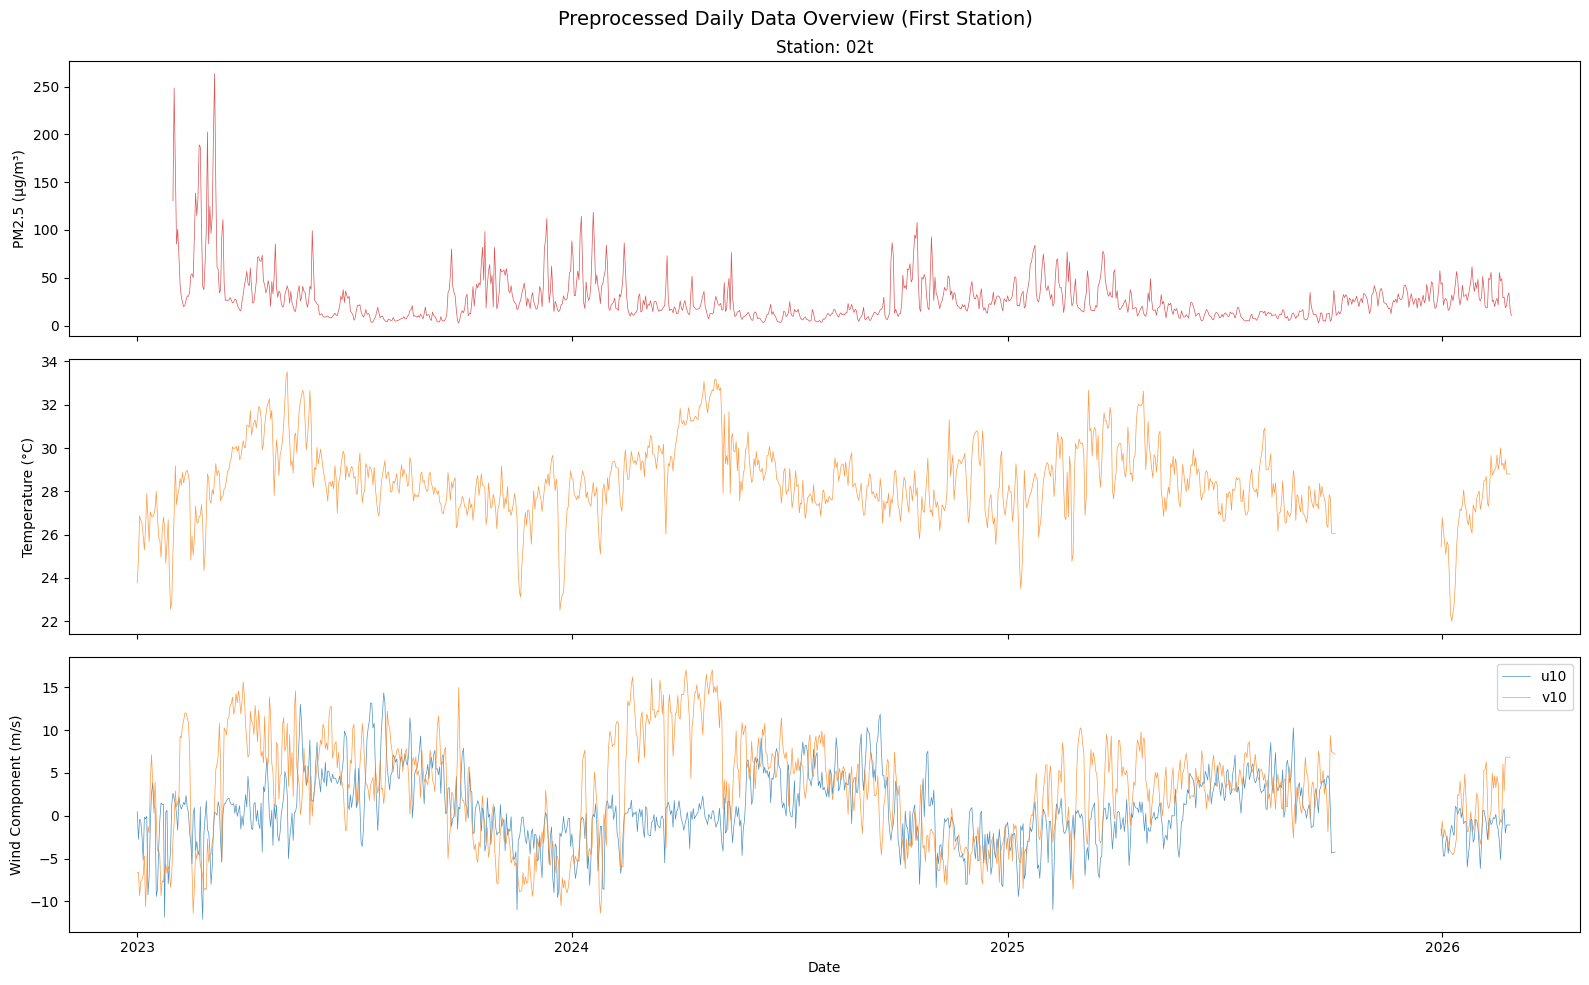

10:16:50 [INFO] Overview plot saved → /Users/ahcint1n/Desktop/bkk-pm25-data-ingestion/data/gold/model_ready/data_overview.png


In [69]:
try:
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates

    fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
    fig.suptitle("Preprocessed Daily Data Overview (First Station)", fontsize=14)

    first_station = merged_daily["stationID"].iloc[0]
    sdf = merged_daily[merged_daily["stationID"] == first_station].sort_values("date")

    ax = axes[0]
    if TARGET_COL in sdf.columns and not sdf[TARGET_COL].isna().all():
        ax.plot(sdf["date"], sdf[TARGET_COL], linewidth=0.5, color="tab:red", alpha=0.8)
        ax.set_ylabel("PM2.5 (µg/m³)")
    else:
        ax.text(0.5, 0.5, "PM2.5 data not available", transform=ax.transAxes, ha="center", fontsize=12)
    ax.set_title(f"Station: {first_station}")

    ax = axes[1]
    if "temp_c" in sdf.columns:
        ax.plot(sdf["date"], sdf["temp_c"], linewidth=0.5, color="tab:orange", alpha=0.8)
    ax.set_ylabel("Temperature (°C)")

    ax = axes[2]
    if "wind_u10" in sdf.columns and "wind_v10" in sdf.columns:
        ax.plot(sdf["date"], sdf["wind_u10"], linewidth=0.5, label="u10", alpha=0.8)
        ax.plot(sdf["date"], sdf["wind_v10"], linewidth=0.5, label="v10", alpha=0.8)
        ax.legend()
    ax.set_ylabel("Wind Component (m/s)")
    ax.set_xlabel("Date")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    plt.tight_layout()
    fig_path = CFG.output_dir / "data_overview.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    LOG.info("Overview plot saved → %s", fig_path)

except ImportError:
    LOG.info("matplotlib not available — skipping visualization.")

---
## Next Steps

1. **Fix AQ ingestion** — Open-Meteo API parameter names have changed; update `fetch_aq_station()` in Step 1  
2. **Resume weather backfill** — complete 2017 Q4 through 2026  
3. **Integrate VIIRS hotspot data** — implement `compute_transboundary_index()`  
4. **Re-run this notebook** once all data sources are available  
5. **Proceed to Step 3** — ST-UNN model training